## import libaries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

import tensorflow as tf
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,silhouette_score,confusion_matrix
from scipy import stats
import joblib
from pathlib import Path
from sklearn.cluster import KMeans
from sklearn.impute import SimpleImputer

## Make folder

In [2]:
Path('models').mkdir(parents=True,exist_ok=True)
Path('outputs/figures').mkdir(parents=True,exist_ok=True)
Path('outputs').mkdir(parents=True,exist_ok=True)
Path('notebooks').mkdir(parents=True,exist_ok=True)
Path('data/raw').mkdir(parents=True,exist_ok=True)
Path('src').mkdir(parents=True,exist_ok=True)

In [3]:
from pathlib import Path
import numpy as np
import pandas as pd
rng = np.random.default_rng(202)
n = 300
cols = ['distance', 'load', 'traffic', 'staff']
x = rng.normal(size=(n, 4))
group = rng.choice(["G1", "G2"], size=n)
score = x @ np.array([0.6, 0.9, 1.2, -0.8])
score += 0.4 * (group == "G2") + rng.normal(0, 1, n)
y = (score > 0).astype(int)
df = pd.DataFrame(np.round(50 + 10*x, 2), columns=cols)
df.insert(0, "record_id", np.arange(1, n+1))
df["group"] = group
df["late"] = y
for col in cols[:2]:
    df.loc[rng.choice(n, 15, replace=False), col] = np.nan
df = pd.concat([df, df.iloc[:5]], ignore_index=True)
Path("data/raw").mkdir(parents=True, exist_ok=True)
df.to_csv("data/raw/set_c.csv", index=False)


## Load csv file

In [4]:
df_raw = pd.read_csv('data/raw/set_c.csv')

## Basic information

In [5]:
df_raw.shape

(305, 7)

In [6]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 305 entries, 0 to 304
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   record_id  305 non-null    int64  
 1   distance   290 non-null    float64
 2   load       290 non-null    float64
 3   traffic    305 non-null    float64
 4   staff      305 non-null    float64
 5   group      305 non-null    str    
 6   late       305 non-null    int64  
dtypes: float64(4), int64(2), str(1)
memory usage: 16.8 KB


In [7]:
df_raw.describe()

,record_id,distance,load,traffic,staff,late
count,305.000000,290.000000,290.000000,305.000000,305.000000,305.000000
mean,148.081967,48.952517,50.152241,49.247115,50.643574,0.488525
std,88.052447,10.494418,10.721161,10.019465,9.251333,0.500690
min,1.000000,24.340000,16.600000,23.140000,23.060000,0.000000
25%,72.000000,42.552500,42.200000,42.010000,44.990000,0.000000
50%,148.000000,48.880000,50.205000,50.110000,50.710000,0.000000
75%,224.000000,56.307500,57.285000,55.590000,56.910000,1.000000
max,300.000000,83.000000,79.750000,78.690000,80.140000,1.000000


## Removes duplicates

In [8]:
df_clean = df_raw.drop_duplicates().copy()

## Final check

In [9]:
print('Clean shape:',df_clean.shape)
print('Original shape:',df.shape)


Clean shape: (300, 7)
Original shape: (305, 7)


## train test spilt

In [10]:
train_full,test_df = train_test_split(df_clean,test_size=0.2,random_state=42,stratify=df_clean['late'])

In [11]:
print('Training partition :',train_full.shape)
print('Testing partition :',test_df.shape)

Training partition : (240, 7)
Testing partition : (60, 7)


In [12]:
fit_df,val_df = train_test_split(train_full,test_size=0.2,random_state=42,stratify=train_full['late'])

In [13]:
print('Fit Training partition :',fit_df.shape)
print('Validation Trainingpartition :',val_df.shape)

Fit Training partition : (192, 7)
Validation Trainingpartition : (48, 7)


## Task 1 — Maths & Adv Stats

# M1 — Descriptive Statistics

In [14]:
observed_distance = fit_df['distance'].dropna()

In [15]:
distance_mean = observed_distance.mean()
distance_std = observed_distance.std(ddof=1)
distance_median = observed_distance.median()
distance_count = observed_distance.count()

## Display

In [16]:
Descriptive_Statistics = pd.DataFrame({
    'variable' : ['distance'],
    'N' : [distance_count],
    'Mean' :[distance_mean],
    'Median' :[distance_median],
    'Std' :[distance_std]
})

In [17]:
display(Descriptive_Statistics)

Descriptive_Statistics.to_csv('outputs/Statistical_Inference.csv',index=False)

,variable,N,Mean,Median,Std
0,distance,184,49.744402,50.2,10.835872


## Histogram_distance

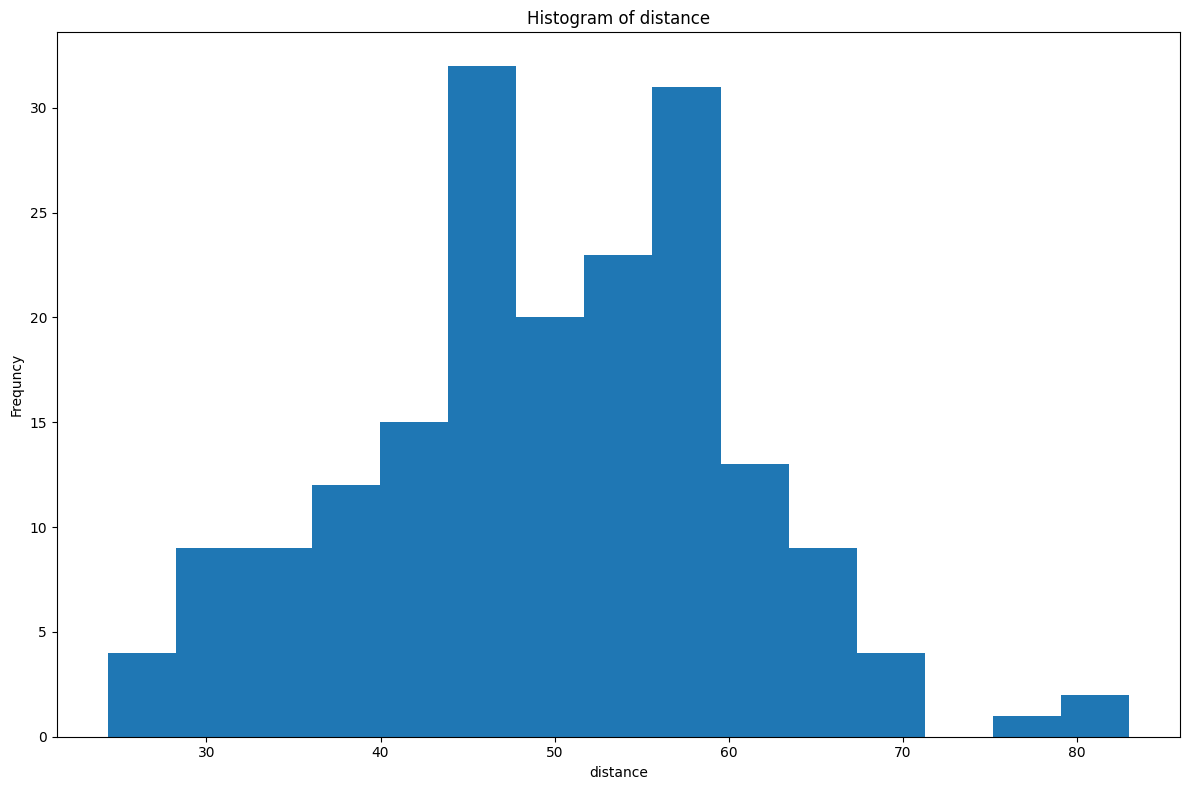

In [18]:
plt.figure(figsize=(12,8))

plt.hist(observed_distance,bins=15)

plt.title('Histogram of distance')
plt.xlabel('distance')
plt.ylabel('Frequncy')
plt.tight_layout()
plt.savefig('outputs/figures/histogram_distance.png')
plt.show()

## M2 — Statistical Inference

In [19]:
g1_distance = fit_df.loc[fit_df['group']=='G1','distance'].dropna()
g2_distance = fit_df.loc[fit_df['group']=='G2','distance'].dropna()

In [20]:
len(g1_distance)

104

In [21]:
len(g2_distance)

80

In [22]:
t_stats,p_v_ = stats.ttest_ind(g1_distance,g2_distance)

## check condition

In [23]:
alpha = 0.05

if p_v_ < alpha:
    print('fail ho')
    print('There is evindence of difference of distance for group 1 and 2 ')
else:
    print('There is not evindence of difference of distance for group 1 and 2 ')    
    print('Fail to reject H0')

There is not evindence of difference of distance for group 1 and 2 
Fail to reject H0


In [24]:
obs_d = len(observed_distance)

mean_d = observed_distance.mean()
mean_std = observed_distance.std(ddof=1)
standard_error = mean_std/np.sqrt(obs_d)
degree_f = obs_d - 1
ci = 0.95

t_critc = stats.t.ppf(
    1-(1-ci),df = degree_f
)

margin_error = t_critc * standard_error

ci_95_lower = mean_d - margin_error
ci_95_upper = mean_d + margin_error

## Interpretation

In [25]:
print('- ttest is used when the sample size is < 30')

print('- observations are trated as indepedant')

print('- ttest is used when the population standard deviation is unknown')

- ttest is used when the sample size is < 30
- observations are trated as indepedant
- ttest is used when the population standard deviation is unknown


## Display

In [26]:
Statistical_Inference = pd.DataFrame({
    'g1_distance' : [len(g1_distance)],
    'g2_distance' : [len(g2_distance)],
    'T critical ' : [t_critc],
    'Margin_error' : [margin_error],
    'ci_95_lower' : [ci_95_lower],
    'ci_95_upper' :[ci_95_upper],
    'P values' :[p_v_],
    'T statistics' : [t_stats]
})

In [27]:
display(Statistical_Inference)

Statistical_Inference.to_csv('outputs/Statistical_Inference.csv',index=False)

,g1_distance,g2_distance,T critical,Margin_error,ci_95_lower,ci_95_upper,P values,T statistics
0,104,80,1.653223,1.320646,48.423756,51.065048,0.480417,0.707087


## M3 — Linear Algebra

In [28]:
linear_data = fit_df[["distance","traffic"]].dropna().copy()

In [29]:
x_linear = linear_data.copy()

print('Shape : ',x_linear.shape)

Shape :  (184, 2)


In [30]:
column_mean = x_linear.mean(axis=0)

X_centered = x_linear - column_mean

print('Column mean:\n',column_mean)
print()
print('X_centered mean :\n',X_centered.mean())

Column mean:
 distance    49.744402
traffic     49.224946
dtype: float64

X_centered mean :
 distance   -8.688702e-15
traffic     4.942906e-15
dtype: float64


## Covariance_matrix

In [31]:
n_complate = X_centered.shape[0]
covariance_matrix = X_centered.T @ X_centered / (n_complate-1)

In [32]:
print('covariance_matrix:\n' ,covariance_matrix)

covariance_matrix:
             distance     traffic
distance  117.416128   -1.236457
traffic    -1.236457  107.433588


## Eigen_values

In [33]:
eigen_values = np.linalg.eigvalsh(covariance_matrix)
print('eigen_values:' ,eigen_values)

eigen_values: [107.28271803 117.56699745]


## largest eigen values

In [34]:
largest_eigen_values = eigen_values.max()

variance_share = largest_eigen_values / eigen_values.sum()

print('Largest eigen_values :',largest_eigen_values)
print('variance_share :',variance_share*100)

Largest eigen_values : 117.56699745404022
variance_share : 52.28692293455573


In [35]:
print('principal direction is directed assigned to the largest eigen values that in late:distance data')
print('variance of from total variance : ',variance_share)

principal direction is directed assigned to the largest eigen values that in late:distance data
variance of from total variance :  0.5228692293455574


## Task 2 — Data Preprocessing & Feature Engineering

# F1 — Audit and Partition

In [36]:
df_raw.shape

(305, 7)

In [37]:
df_raw.isnull().sum()

record_id     0
distance     15
load         15
traffic       0
staff         0
group         0
late          0
dtype: int64

In [38]:
df_raw.duplicated().sum()

5

In [39]:
df_raw['late'].value_counts(normalize=True).sort_index()

late
0    0.511475
1    0.488525
Name: proportion, dtype: float64

In [40]:
fit_id = fit_df['record_id'].copy()
val_id = val_df['record_id'].copy()
test_id = test_df['record_id'].copy()

In [41]:
fit_set = set(fit_id)
val_set = set(val_id)
test_set = set(test_id)

fit_val_overlap = fit_set.intersection(val_set)
fit_test_overlap = fit_set.intersection(test_set)
val_test_overlap = val_set.intersection(test_set)

In [42]:
len(fit_set.intersection(val_set))

0

In [43]:
len(fit_set.intersection(test_set))

0

In [44]:
len(val_set.intersection(test_set))

0

In [45]:
assert len(fit_set.intersection(val_set)) ==0
assert len(fit_set.intersection(test_set))==0
assert len(val_set.intersection(test_set))==0

In [46]:
assert len(fit_df)==192
assert len(val_df)==48
assert len(test_df)==60

In [47]:
print('Alll partition are disjoint')
print('Partition sizes are correct')

Alll partition are disjoint
Partition sizes are correct


## Display

In [48]:
fit_spilt = pd.DataFrame({
    'record_id' : fit_id,
    'partition' : 'fit'
})

val_spilt = pd.DataFrame({
    'record_id' : val_id,
    'partition' : 'validation'
})

test_spilt = pd.DataFrame({
    'record_id' : test_id,
    'partition' : 'test'
})

spilt_df = pd.concat([fit_spilt,val_spilt,test_spilt])

In [49]:
spilt_df.to_csv('outputs/spilt_df.csv',index=False)
display(spilt_df)

,record_id,partition
288,289,fit
73,74,fit
259,260,fit
280,281,fit
243,244,fit
...,...,...
261,262,test
157,158,test
206,207,test
109,110,test


## F2 — Transform and Engineer

In [50]:
numerical_fetures = ['distance','load','traffic','staff']

categorical_fetures = ['group']

target = ['late']

y_fit = fit_df[target].copy()
y_val = val_df[target].copy()
y_test = test_df[target].copy()

## Imputer

In [51]:
imputer = SimpleImputer(strategy='median')

In [52]:
imputer.fit(fit_df[numerical_fetures])

,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feature has nomissing values at fit/train time, the feature won't appear onthe missing indicator even if there are missing values attransform/test time.",False
,"keep_empty_features keep_empty_features: bool, default=FalseIf True, features that consist exclusively of missing values when`fit` is called are returned in results when `transform` is called.The imputed value is always `0` except when `strategy=""constant""`in which case `fill_value` will be used instead... versionadded:: 1.2",False


In [53]:
x_fit_imputer = pd.DataFrame(imputer.transform(fit_df[numerical_fetures]),
                             columns=numerical_fetures,
                             index=fit_df.index)

In [54]:
x_val_imputer = pd.DataFrame(imputer.transform(val_df[numerical_fetures]),
                             columns=numerical_fetures,
                             index=val_df.index)

In [55]:
x_test_imputer = pd.DataFrame(imputer.transform(test_df[numerical_fetures]),
                             columns=numerical_fetures,
                             index=test_df.index)

In [56]:
x_fit_imputer['engineered_feature'] = (x_fit_imputer['load'] / ( x_fit_imputer['staff'] + 1 ))

In [57]:
x_val_imputer['engineered_feature'] = (x_val_imputer['load'] / ( x_val_imputer['staff'] + 1 ))

In [58]:
x_test_imputer['engineered_feature'] = (x_test_imputer['load'] / ( x_test_imputer['staff'] + 1 ))

In [59]:
final_numerical_fetures = ['distance','load','traffic','staff','engineered_feature']

## Scaler

In [60]:
scalar = StandardScaler()

In [61]:
scalar.fit(x_fit_imputer[numerical_fetures])

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [62]:
x_scalar_fit = scalar.transform(x_fit_imputer[numerical_fetures])
x_scalar_val = scalar.transform(x_val_imputer[numerical_fetures])
x_scalar_test = scalar.transform(x_test_imputer[numerical_fetures])



In [63]:
encoder = OneHotEncoder(handle_unknown='ignore',sparse_output=False)

## Encoder

In [64]:
encoder.fit(fit_df[categorical_fetures])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [65]:
x_fit_encoder = encoder.transform(fit_df[categorical_fetures])

In [66]:
x_val_encoder = encoder.transform(val_df[categorical_fetures])

In [67]:
x_test_encoder = encoder.transform(test_df[categorical_fetures])

In [68]:
x_fit = np.hstack([
    x_fit_imputer,x_fit_encoder
])

x_val = np.hstack([
    x_val_imputer,x_val_encoder
])

x_test = np.hstack([
    x_test_imputer,x_test_encoder
])

## F3 — Leakage Evidence

In [69]:
final_categorical_featues = encoder.get_feature_names_out(categorical_fetures).tolist()
print(final_categorical_featues)

['group_G1', 'group_G2']


In [70]:
final_combine_featues = (final_numerical_fetures + final_categorical_featues)

for featues in final_combine_featues:
    print('-',featues)

- distance
- load
- traffic
- staff
- engineered_feature
- group_G1
- group_G2


In [71]:
print('X fit shape : ',x_fit.shape)
print('X validation shape : ',x_val.shape)
print('X test shape : ',x_test.shape)

X fit shape :  (192, 7)
X validation shape :  (48, 7)
X test shape :  (60, 7)


In [72]:
print('X fit finite : ',np.isfinite(x_fit).all())

X fit finite :  True


In [73]:
print('X validation finite : ',np.isfinite(x_val).all())

X validation finite :  True


In [74]:
print('X test finite : ',np.isfinite(x_test).all())

X test finite :  True


## Interpretation

In [75]:
print('- late is excutes because it is targeter')
print('- record id is excutes because it is identifier')
print('- imputer,scaler,encoder is done on 192 fit records')
print('- validation and test records is not used for this tranformation')

- late is excutes because it is targeter
- record id is excutes because it is identifier
- imputer,scaler,encoder is done on 192 fit records
- validation and test records is not used for this tranformation


## Save model

In [76]:
joblib.dump(encoder,'models/encoder.joblib')

['models/encoder.joblib']

In [77]:
joblib.dump(scalar,'models/scalar.joblib')

['models/scalar.joblib']

In [78]:
joblib.dump(imputer,'models/imputer.joblib')

['models/imputer.joblib']

## Task 3 — Supervised Learning

## Dummy classifier

In [79]:
dummy_model = DummyClassifier(strategy='most_frequent',random_state=42)

In [80]:
dummy_model.fit(x_fit,y_fit)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'most_frequent'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None


In [81]:
dummy_prd = dummy_model.predict(x_test)

## Metrics

In [82]:
dummy_accuracy = accuracy_score(y_test,dummy_prd) * 100
dummy_precision = precision_score(y_test,dummy_prd) * 100
dummy_recall = recall_score(y_test,dummy_prd) * 100
dummy_f1score = f1_score(y_test,dummy_prd) * 100

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## Logistic regression

In [83]:
log_model = LogisticRegression(random_state=42,max_iter=1000)

In [84]:
log_model.fit(x_fit,y_fit)

c:\Users\hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

In [85]:
print('Random state : 42')
print()
print('max_iter:1000')
print()

print('- Featues:',final_combine_featues)
print()

print('targest:',target)

Random state : 42

max_iter:1000

- Featues: ['distance', 'load', 'traffic', 'staff', 'engineered_feature', 'group_G1', 'group_G2']

targest: ['late']


## S2 — Holdout Evaluation

In [86]:
log_prob = log_model.predict_proba(x_test)[:,1]

In [87]:
log_prob[:10]

array([0.02109389, 0.05673853, 0.00311218, 0.06794687, 0.02507266,
       0.79972746, 0.98341651, 0.01472049, 0.96782773, 0.0707617 ])

In [88]:
log_prd = (log_prob > 0.5).astype(int)

In [89]:
log_prd[:10]

array([0, 0, 0, 0, 0, 1, 1, 0, 1, 0])

## Metrics

In [90]:
log_score = accuracy_score(y_test,log_prd ) * 100

log_f1score = f1_score(y_test,log_prd,zero_division=0) * 100
log_recallscore = recall_score(y_test,log_prd ,zero_division=0) * 100
log_presicionscore = precision_score(y_test,log_prd ,zero_division=0) * 100

## Display

In [91]:
per_record_test_logistic = pd.DataFrame({
    'record_id' : test_df['record_id'].to_numpy().reshape(-1),
    'true label' :np.asarray(y_test).reshape(-1),
    'predicted_label' :np.asarray(log_prd).reshape(-1),
    'class-1_probability' : np.asarray(log_prob).reshape(-1)
})

In [92]:
display(per_record_test_logistic[:10])

per_record_test_logistic.to_csv('outputs/per_record_test_logistic.csv',index=False)

,record_id,true label,predicted_label,class-1_probability
0,50,0,0,0.021094
1,231,0,0,0.056739
2,297,0,0,0.003112
3,97,0,0,0.067947
4,285,0,0,0.025073
5,116,0,1,0.799727
6,38,1,1,0.983417
7,76,0,0,0.014720
8,51,1,1,0.967828
9,100,0,0,0.070762


## Confusion matrix

In [93]:
cm = confusion_matrix(y_test,log_prd)

C:\Users\hp\AppData\Local\Temp\ipykernel_14116\153707005.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


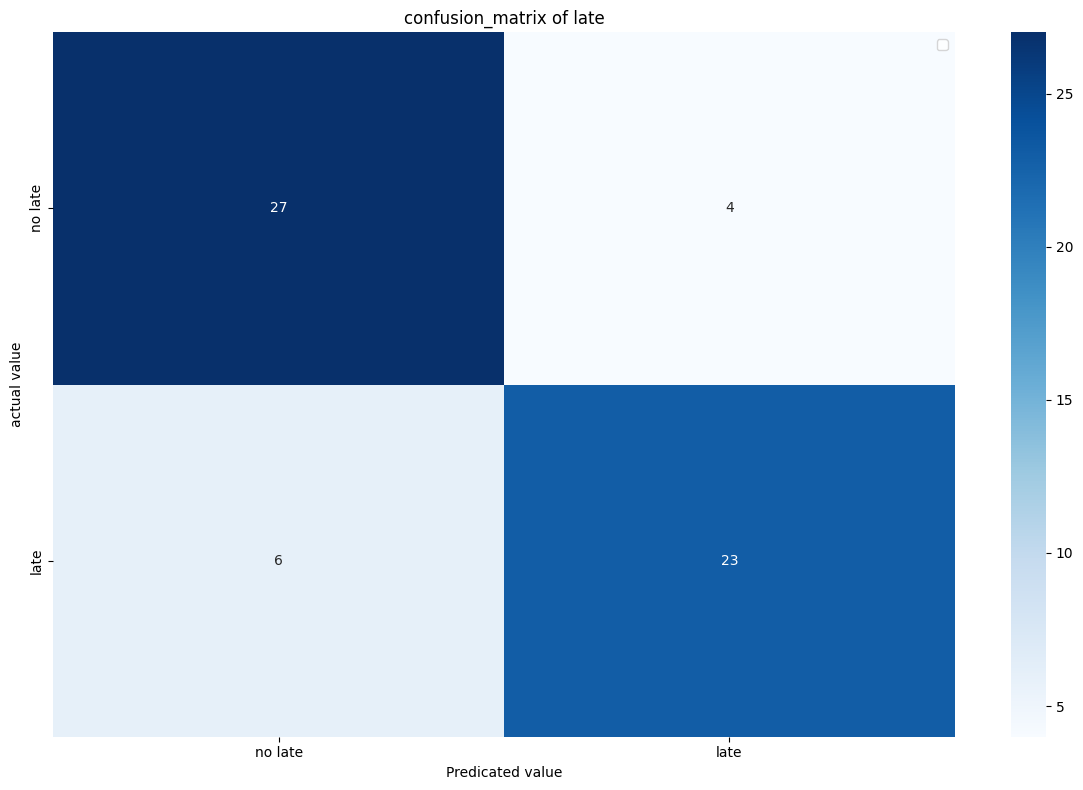

In [94]:
plt.figure(figsize=(12,8))

sns.heatmap(cm,cmap='Blues',annot=True,fmt='d',xticklabels=['no late','late'],yticklabels=['no late','late'])
plt.title('confusion_matrix of late')
plt.xlabel('Predicated value')
plt.ylabel('actual value')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/figures/confusion_matrix.png')
plt.show()

## S3 — Interpretation

In [95]:
tn,fp,fn,tp = cm.ravel()

print('False positive :',fp)
print('False Negative :',fn)

False positive : 4
False Negative : 6


In [96]:
print('false positive : ',fp)
print('The delivery is not late but model predict the delievery is late')
print()
print('false Negative : ',fn)
print('The delivery is  late but model predict the delievery is not late')




false positive :  4
The delivery is not late but model predict the delievery is late

false Negative :  6
The delivery is  late but model predict the delievery is not late


## Interpretation

In [97]:
if log_score > dummy_accuracy:
    print('logistic model is selected based on accuracy score')
else:
    print('Dummy baseline classifier model is selected based on accuracy score')    

logistic model is selected based on accuracy score


In [98]:
metrics_result = pd.DataFrame({
    'models' :['DummyClassifier','LogisticRegression'],
    'F1 score' :[dummy_f1score,log_f1score],
    'Recall' :[dummy_recall,log_recallscore],
    'Presicion ' : [dummy_precision,log_presicionscore],
    'Accuracy' :[dummy_accuracy,log_score]
})

In [99]:
display(metrics_result)

metrics_result.to_csv('outputs/metrics_result.csv',index=False)

,models,F1 score,Recall,Presicion,Accuracy
0,DummyClassifier,0.000000,0.000000,0.000000,51.666667
1,LogisticRegression,82.142857,79.310345,85.185185,83.333333


## Task 4 — Unsupervised Learning

In [100]:
x_cluster = x_scalar_fit.copy()

clusters_featues = ['distance', 'load', 'traffic', 'staff', 'engineered_feature']

print('Shape : ',x_cluster.shape)
print('Featues : ',clusters_featues)

Shape :  (192, 4)
Featues :  ['distance', 'load', 'traffic', 'staff', 'engineered_feature']


In [101]:
kmean_model2 = KMeans(n_clusters=2,n_init=10,random_state=42)

label2 = kmean_model2.fit_predict(x_cluster)

score_2 = silhouette_score(x_cluster,label2) 
print('K = 2')

print('inertia :',kmean_model2.inertia_)

print('silhouette_score :',score_2)


K = 2
inertia : 623.6617935984314
silhouette_score : 0.17871497855671226


In [102]:
kmean_model3 = KMeans(n_clusters=3,n_init=10,random_state=42)

label3 = kmean_model3.fit_predict(x_cluster)

score_3 = silhouette_score(x_cluster,label3) 
print('K = 3')

print('inertia :',kmean_model3.inertia_)

print('silhouette_score :',score_3)

K = 3
inertia : 524.0772179199887
silhouette_score : 0.17590427825025814


In [103]:
kmean4_model = KMeans(n_clusters=4,n_init=10,random_state=42)

label4 = kmean4_model.fit_predict(x_cluster)

score_4 = silhouette_score(x_cluster,label4) 
print('K = 4')

print('inertia :',kmean4_model.inertia_)

print('silhouette_score :',score_4)

K = 4
inertia : 454.6945033856
silhouette_score : 0.19115460854222066


In [104]:
kmean_result = pd.DataFrame({
    'k' : [2,3,4],
    'inertia' : [kmean_model2.inertia_,kmean_model3.inertia_,kmean4_model.inertia_],
    'silhouette_score' :[score_2,score_3,score_4]
    
})

display(kmean_result)

kmean_result.to_csv('outputs/kmean_result.csv',index=False)


,k,inertia,silhouette_score
0,2,623.661794,0.178715
1,3,524.077218,0.175904
2,4,454.694503,0.191155


In [105]:
best_row = kmean_result.sort_values(by=['silhouette_score','k'],ascending=[False,True]).iloc[0]

best_k = int(best_row['k'])

print('Best k : ',best_k)

print('Best silhouette_score :',best_row['silhouette_score'])


Best k :  4
Best silhouette_score : 0.19115460854222066


In [106]:
if best_k == 2:
    best_kmean = kmean_model2,
    best_label = label2
elif best_k ==3:
    best_kmean = kmean_model3,
    best_label = label3    
else:
    best_kmean = kmean4_model,
    best_label = label4 

In [107]:
cluster_data = x_fit_imputer[clusters_featues].copy()

cluster_data['Cluster'] = best_label

cluster_profile = cluster_data.groupby('Cluster').mean()

display(cluster_profile)

cluster_profile.to_csv('outputs/cluster_profile.csv',index=False)

,distance,load,traffic,staff,engineered_feature
Cluster,,,,,
0,35.865500,49.394875,51.486250,54.814500,0.901314
1,52.313860,57.579474,40.299123,52.176491,1.107753
2,55.978684,56.673421,58.323684,42.131316,1.355505
3,52.822281,39.236930,50.767368,50.452807,0.782525


In [108]:
cluster_size = cluster_data['Cluster'].value_counts().sort_index()

display(cluster_size)



Cluster
0    40
1    57
2    38
3    57
Name: count, dtype: int64

In [109]:
overall_mean = cluster_data[clusters_featues].mean()

display(overall_mean)

distance              49.763385
load                  50.249583
traffic               49.304896
staff                 50.226250
engineered_feature     1.017227
dtype: float64

## Interpretation

In [110]:
print(
    "- Cluster IDs are arbitrary labels and do not represent "
    "late target classes."
)

print(
    "- Only the 192 fit records and numeric predictor features "
    "were used for cluster selection."
)

print(
    "- Test data and late target labels were not used "
    "to choose the clusters.")

- Cluster IDs are arbitrary labels and do not represent late target classes.
- Only the 192 fit records and numeric predictor features were used for cluster selection.
- Test data and late target labels were not used to choose the clusters.


In [111]:
joblib.dump(best_kmean,'models/best_kmean.joblib')

['models/best_kmean.joblib']

## Task 5 — Deep Learning up to ANN

# D1 — ANN Architecture and Compilation

In [112]:
tf.keras.utils.set_random_seed(42)

print('Random state : 42')

Random state : 42


## Model Buliding

In [113]:
ann_model = tf.keras.Sequential([
    tf.keras.Input(shape=(x_fit.shape[1],)),
    
    tf.keras.layers.Dense(16,activation='relu'),
    tf.keras.layers.Dense(8,activation='relu'),
    tf.keras.layers.Dense(1,activation='sigmoid'),

])

## Model comple

In [114]:
ann_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),loss='binary_crossentropy',metrics=['accuracy'])

## Summary 

In [115]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 273 (1.07 KB)

 Trainable params: 273 (1.07 KB)

 Non-trainable params: 0 (0.00 B)

## Trainables parameter

In [116]:
total_parameter = np.sum([
    np.prod(weight.shape)
    for weight in ann_model.trainable_weights
])

print('total_parameter:',total_parameter)

total_parameter: 273


## Interpretation

In [117]:
print('- Binary cross entropy is used because binary classification for class separation ')
print('- Adam optimizer is also used with learning rate 0.001')
print('- we can sue relu function for max(0,max) or sigmoid function for output layer in convert to 0 and 1')

- Binary cross entropy is used because binary classification for class separation 
- Adam optimizer is also used with learning rate 0.001
- we can sue relu function for max(0,max) or sigmoid function for output layer in convert to 0 and 1


## callbacks

In [118]:
early_callbacks = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True)

## Model fit

In [119]:
history = ann_model.fit(x_fit,y_fit,validation_data=(x_val,y_val),batch_size=14,epochs=50,verbose=-1,callbacks=[early_callbacks])

Epoch 1/50
Epoch 2/50
Epoch 3/50
Epoch 4/50
Epoch 5/50
Epoch 6/50
Epoch 7/50
Epoch 8/50
Epoch 9/50
Epoch 10/50
Epoch 11/50
Epoch 12/50
Epoch 13/50
Epoch 14/50
Epoch 15/50
Epoch 16/50
Epoch 17/50
Epoch 18/50
Epoch 19/50
Epoch 20/50
Epoch 21/50
Epoch 22/50
Epoch 23/50
Epoch 24/50
Epoch 25/50
Epoch 26/50
Epoch 27/50
Epoch 28/50
Epoch 29/50
Epoch 30/50
Epoch 31/50
Epoch 32/50
Epoch 33/50
Epoch 34/50
Epoch 35/50
Epoch 36/50
Epoch 37/50
Epoch 38/50
Epoch 39/50
Epoch 40/50
Epoch 41/50
Epoch 42/50
Epoch 43/50
Epoch 44/50
Epoch 45/50
Epoch 46/50
Epoch 47/50
Epoch 48/50
Epoch 49/50
Epoch 50/50


In [120]:
total_ephochs = len(history.history['loss'])
print('Total ephocs:',total_ephochs)

Total ephocs: 50


## Ann_loss_curve

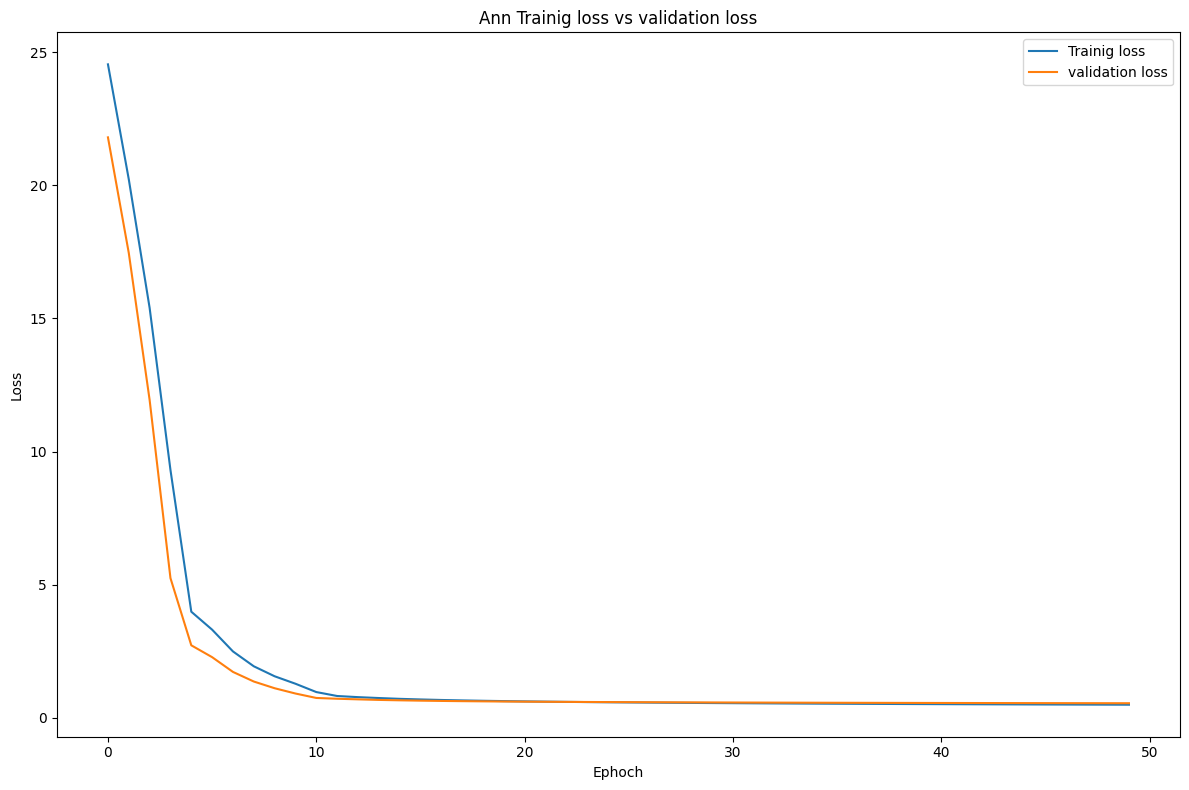

In [121]:
plt.figure(figsize=(12,8))

plt.plot(history.history['loss'],label='Trainig loss')

plt.plot(history.history['val_loss'],label='validation loss')
plt.title('Ann Trainig loss vs validation loss')
plt.xlabel('Ephoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.legend()
plt.savefig('outputs/figures/ann_loss_curve.png')
plt.show()

## Overfitting Vs Underfitting

In [122]:
final_val_loss = history.history['val_loss'][-1]
final_training_loss = history.history['loss'][-1]

print('Final validation loss :',final_val_loss)
print('Final Training loss :',final_training_loss)


print('If the Training loss is decrase and validation loss is increase is called over fitting')
print('If the Training loss is high and validation loss is high is called under fitting')

Final validation loss : 0.544135570526123
Final Training loss : 0.4885580241680145
If the Training loss is decrase and validation loss is increase is called over fitting
If the Training loss is high and validation loss is high is called under fitting


## Class 1 probability

In [123]:
prob_ann = ann_model.predict(x_test).reshape(-1)
print(prob_ann[:10])

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
[0.18351088 0.26748797 0.20650905 0.12844893 0.09824798 0.5584926
 0.68249154 0.3793052  0.72717357 0.22694185]


## Predict

In [124]:
prd_ann = (prob_ann>0.5).astype(int)
print(prd_ann[:10])

[0 0 0 0 0 1 1 0 1 0]


## Metrics

In [125]:
ann_accuracy = accuracy_score(y_test,prd_ann) * 100
ann_precision = precision_score(y_test,prd_ann) * 100
ann_recall = recall_score(y_test,prd_ann) * 100
ann_f1score = f1_score(y_test,prd_ann) * 100

## Display

In [126]:
ann_pre_records_result = pd.DataFrame({
    'Record_id' : test_df['record_id'].to_numpy().reshape(-1),
    ' true label':np.asarray(y_test).reshape(-1),
    ' predicted label ':np.asarray(prd_ann).reshape(-1),
    'class-1 probability':np.asarray(prob_ann).reshape(-1)
})

display(ann_pre_records_result[:10])

ann_pre_records_result.to_csv('outputs/ann_pre_records_result.csv',index=False)

,Record_id,true label,predicted label,class-1 probability
0,50,0,0,0.183511
1,231,0,0,0.267488
2,297,0,0,0.206509
3,97,0,0,0.128449
4,285,0,0,0.098248
5,116,0,1,0.558493
6,38,1,1,0.682492
7,76,0,0,0.379305
8,51,1,1,0.727174
9,100,0,0,0.226942


## Interpretation

In [127]:
print('LogisticRegression f1 score :',log_f1score)
print('ann  f1 score :',ann_f1score)

if ann_f1score > log_f1score:
    print('Ann model is selected based on f1 score')
else:
    print('Logistic model is selected based on f1 score')    

LogisticRegression f1 score : 82.14285714285714
ann  f1 score : 73.68421052631578
Logistic model is selected based on f1 score


## Final metrics

In [128]:
final_metrics = pd.DataFrame({
    'models' :['LogisticRegression','dummy classifier','ANN'],
    'F1 Score' :[log_f1score,dummy_f1score,ann_f1score],
    'Recall' :[log_recallscore,dummy_recall,ann_recall],
    'Presicion' :[log_presicionscore,dummy_precision,ann_precision],
    'Accuracy' :[log_score,dummy_accuracy,ann_accuracy]
})

display(final_metrics)

final_metrics.to_csv('outputs/final_metrics.csv',index=False)

,models,F1 Score,Recall,Presicion,Accuracy
0,LogisticRegression,82.142857,79.310345,85.185185,83.333333
1,dummy classifier,0.000000,0.000000,0.000000,51.666667
2,ANN,73.684211,72.413793,75.000000,75.000000


## Save model

In [129]:
ann_model.save('models/ann_model.keras')